In [1]:
import numpy as np
from to_RGB import to_rgb

def rgb_to_8_bit(three_channel_tensor):
    pred_array = np.asarray(three_channel_tensor)
    
    return np.argmax(pred_array, axis=2)

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from pathlib import Path

needle_path_1 = r"C:\Users\magfa\Documents\Master\Masteroppgave\dataset_generation\script and needles\needles\image.png"
needle_path_2 = r"C:\Users\magfa\Documents\Master\Masteroppgave\dataset_generation\script and needles\needles\Rs_m004.png"
needle_path_3 = r"C:\Users\magfa\Documents\Master\Masteroppgave\dataset_generation\script and needles\needles\Rs_m006.png"

script_path_1 = r"C:\Users\magfa\Documents\Master\Masteroppgave\dataset_generation\script and needles\script\org_10nbr_2_upscaled_chinese_gaussian.png"
script_path_2 = r"C:\Users\magfa\Documents\Master\Masteroppgave\dataset_generation\script and needles\script\org_0nbr_9_upscaled_chinese_gaussian.png"
script_path_3 = r"C:\Users\magfa\Documents\Master\Masteroppgave\dataset_generation\script and needles\script\org_3nbr_8_upscaled_chinese_gaussian.png"

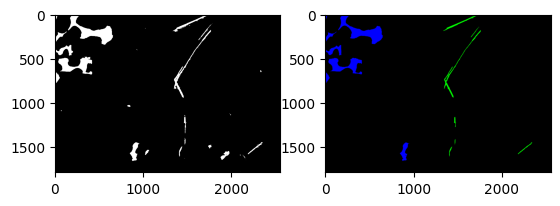

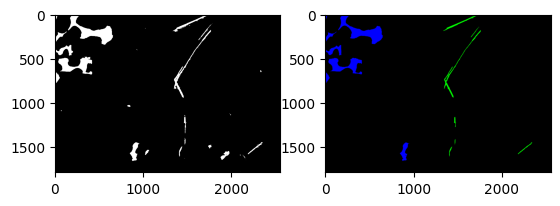

In [ ]:
raw = r"C:\Users\magfa\Documents\Master\Masteroppgave\src\dataset_3_before_correct_labels\Mask of org_0nbr_5_upscaled_2m_raw.png"
label = r"C:\Users\magfa\Documents\Master\Masteroppgave\src\dataset_3_before_correct_labels\Mask of org_0nbr_5_upscaled_2m.png"

img_raw = Image.open(raw)
img_label = Image.open(label)

arr_raw = np.asarray(img_raw)
arr_label = np.asarray(img_label)

arr_label = to_rgb(arr_label).astype(np.uint8)

fig, ax = plt.subplots(1, 2)
ax[0].imshow(arr_raw, cmap = "Greys_r")
ax[1].imshow(arr_label)
fig

In [3]:
needle_1 = Image.open(needle_path_1)
needle_2 = Image.open(needle_path_2)
needle_3 = Image.open(needle_path_3)

script_1 = Image.open(script_path_1)
script_2 = Image.open(script_path_2)
script_3 = Image.open(script_path_3)

In [4]:
needle_arr_1 = np.asarray(needle_1)
needle_arr_2 = np.asarray(needle_2)
needle_arr_3 = np.asarray(needle_3)

script_arr_1 = np.asarray(script_1)
script_arr_2 = np.asarray(script_2)
script_arr_3 = np.asarray(script_3)

In [5]:
needle_arr_1 = needle_arr_1[:1432, :]
needle_arr_2 = needle_arr_2[:1790, :]
needle_arr_3 = needle_arr_3[:1790, :]

img = Image.fromarray(needle_arr_1)
img = img.resize((2560, 1790), Image.Resampling.NEAREST)

needle_arr_1 = np.asarray(img)
print(np.unique(needle_arr_1))

[  0 255]


In [6]:
print(np.unique(needle_arr_1))

[  0 255]


In [7]:
needle_arr_1 = needle_arr_1 // needle_arr_1.max()
needle_arr_2 = needle_arr_2 // needle_arr_2.max()
needle_arr_3 = needle_arr_3 // needle_arr_3.max()
 
script_arr_1 = script_arr_1 // script_arr_1.max()
script_arr_2 = script_arr_2 // script_arr_2.max()
script_arr_3 = script_arr_3 // script_arr_3.max()

print(np.unique(needle_arr_1))

[0 1]


In [8]:
raw1 = needle_arr_1 + script_arr_1
raw2 = needle_arr_2 + script_arr_2
raw3 = needle_arr_3 + script_arr_3

print(np.unique(raw1))

raw1 = (raw1 > 0).astype(int)
raw2 = (raw2 > 0).astype(int)
raw3 = (raw3 > 0).astype(int)

print(np.unique(raw1))
print(np.unique(raw2))
print(np.unique(raw3))

[0 1 2]
[0 1]
[0 1]
[0 1]


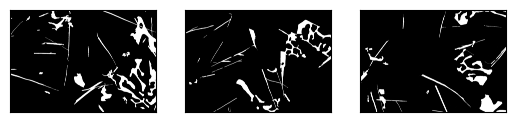

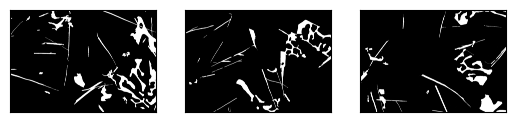

In [9]:
raw1_255 = (raw1 * 255).astype(np.uint8)
raw2_255 = (raw2 * 255).astype(np.uint8)
raw3_255 = (raw3 * 255).astype(np.uint8)

fig, axarr = plt.subplots(1, 3)

flat = axarr.flatten()

flat[0].imshow(raw1_255, cmap = "Greys_r")
flat[1].imshow(raw2_255, cmap = "Greys_r")
flat[2].imshow(raw3_255, cmap = "Greys_r")

for ax in flat:
    ax.set_xticks([])
    ax.set_yticks([])

fig

In [10]:
img1 = Image.fromarray(raw1_255)
img2 = Image.fromarray(raw2_255)
img3 = Image.fromarray(raw3_255)

img1.save(r"C:\Users\magfa\Documents\Master\Masteroppgave\dataset_generation\script and needles\raw\raw1.png")
img2.save(r"C:\Users\magfa\Documents\Master\Masteroppgave\dataset_generation\script and needles\raw\raw2.png")
img3.save(r"C:\Users\magfa\Documents\Master\Masteroppgave\dataset_generation\script and needles\raw\raw3.png")

In [11]:
script_arr_1 = script_arr_1 * 2
script_arr_2 = script_arr_2 * 2
script_arr_3 = script_arr_3 * 2

In [19]:
def to_rgb(array):
    h, w = array.shape

    img = np.zeros((h, w, 3), dtype=np.uint8)

    red_channel = (array == 0).astype(np.uint8) * 0
    green_channel = (array == 1).astype(np.uint8) * 255
    blue_channel = (array == 2).astype(np.uint8) * 255

    img[:, :, 0] = red_channel
    img[:, :, 1] = green_channel
    img[:, :, 2] = blue_channel

    return img

In [13]:
label1 = needle_arr_1 + script_arr_1
label2 = needle_arr_2 + script_arr_2
label3 = needle_arr_3 + script_arr_3

label1_overlap = (label1 == 3)
label2_overlap = (label2 == 3)
label3_overlap = (label3 == 3)

label1 = label1 - label1_overlap
label2 = label2 - label2_overlap
label3 = label3 - label3_overlap

label1_overlap = (label1_overlap // 3) * 2 
label2_overlap = (label2_overlap // 3) * 2
label3_overlap = (label3_overlap // 3) * 2

label1 = label1 + label1_overlap
label2 = label2 + label2_overlap
label3 = label3 + label3_overlap

label1_rgb = to_rgb(label1).astype(np.uint8)
label2_rgb = to_rgb(label2).astype(np.uint8)
label3_rgb = to_rgb(label3).astype(np.uint8)

In [14]:
img1 = Image.fromarray(label1_rgb)
img2 = Image.fromarray(label2_rgb)
img3 = Image.fromarray(label3_rgb)

img1.save(r"C:\Users\magfa\Documents\Master\Masteroppgave\dataset_generation\script and needles\label\label1.png")
img2.save(r"C:\Users\magfa\Documents\Master\Masteroppgave\dataset_generation\script and needles\label\label2.png")
img3.save(r"C:\Users\magfa\Documents\Master\Masteroppgave\dataset_generation\script and needles\label\label3.png")

Calculate class weights

In [ ]:
path = r"C:\Users\magfa\Documents\Master\Masteroppgave\src\dataset_3_before_correct_labels\dataset_3_labels_redone\train_label"
folder = Path(path)

nbr_classes = 3

nbr_background_pixels = 0
nbr_needle_pixels = 0
nbr_script_pixels = 0

image_count = 0

for file in folder.iterdir():
    image_count += 1
    img = Image.open(file)
    arr = np.asarray(img)
    unique, counts = np.unique(arr, return_counts = True)[0], np.unique(arr, return_counts = True)[1]
    nbr_background_pixels += counts[0]
    if len(unique) == 3:
        nbr_needle_pixels += counts[1]
        nbr_script_pixels += counts[2]
    elif len(unique) == 2:
        if unique[1] == 1:
            nbr_needle_pixels += counts[1]
        else:
            nbr_script_pixels += counts[1]

total_pixels = nbr_background_pixels + nbr_needle_pixels + nbr_script_pixels

background_weight = total_pixels / (nbr_classes * nbr_background_pixels)
needle_weight = total_pixels / (nbr_classes * nbr_needle_pixels)
script_weight = total_pixels / (nbr_classes * nbr_script_pixels)

sum_weights = background_weight + needle_weight + script_weight

background_weight = background_weight / (nbr_classes * sum_weights)
needle_weight = needle_weight / (nbr_classes * sum_weights)
script_weight = script_weight / (nbr_classes * sum_weights)

print(f"Background weight: {background_weight:>4f}, Needle weight: {needle_weight:>4f}, Script weight: {script_weight:>4f}")

Background weight: 0.003304, Needle weight: 0.203288, Script weight: 0.126741


In [4]:
path = r"C:\Users\magfa\Documents\Master\Masteroppgave\data\two-step model datasets\step 1 phase extraction\train\label"
folder = Path(path)

nbr_classes = 3

nbr_background_pixels = 0
nbr_needle_pixels = 0
nbr_script_pixels = 0

for file in folder.iterdir():
    img = Image.open(file)
    arr = np.asarray(img)

    unique, cnt = np.unique(arr, return_counts=True)

    for value, count in zip(unique, cnt):
        if value == 0:
            nbr_background_pixels += count
        elif value == 1:
            nbr_needle_pixels += count
        elif value == 2:
            nbr_script_pixels += count

    total_pixels = nbr_background_pixels + nbr_needle_pixels + nbr_script_pixels

    background_weight = total_pixels / (nbr_classes * nbr_background_pixels)
    needle_weight = total_pixels / (nbr_classes * nbr_needle_pixels)
    script_weight = total_pixels / (nbr_classes * nbr_script_pixels)

    #background_weight = background_weight ** 0.5
    #needle_weight = needle_weight ** 0.5
    #script_weight = script_weight ** 0.5

print(f"Background weight: {background_weight:>4f}, Needle weight: {needle_weight:>4f}, Script weight: {script_weight:>4f}")

C:\Users\magfa\AppData\Local\Temp\ipykernel_6084\3572336444.py:28: RuntimeWarning: divide by zero encountered in scalar divide
  script_weight = total_pixels / (nbr_classes * nbr_script_pixels)


Background weight: 0.346777, Needle weight: 8.598215, Script weight:  inf


In [ ]:
path = r"C:\Users\magfa\Documents\Master\Masteroppgave\machine_learning\predictions\improved_dataset_2_first_run\30.png"
path2 = r"C:\Users\magfa\Documents\Master\Masteroppgave\dataset_generation\improved_dataset_2\test\label\292.png"

img = Image.open(path)
img2 = Image.open(path2)

arr = np.asarray(img)
arr2 = np.asarray(img2)

print(arr.shape)
print(arr2.shape)

(1790, 2560, 3)
(2560, 1790)


In [11]:
eight_bit_arr = rgb_to_8_bit(arr).astype(np.uint8)

print(np.unique(eight_bit_arr, return_counts = True))
print(np.unique(arr2, return_counts = True))

(array([0, 1, 2], dtype=uint8), array([4414295,   58232,  109873], dtype=int64))
(array([0, 1, 2], dtype=uint8), array([4414297,   58202,  109901], dtype=int64))


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


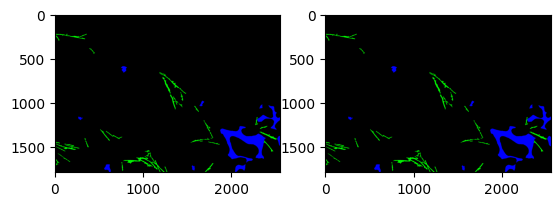

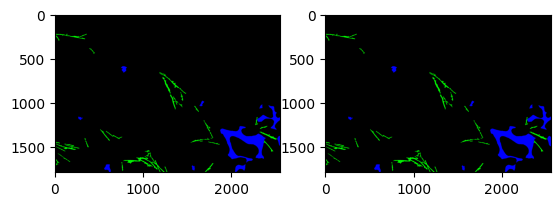

In [14]:
rgb_prediction = to_rgb(eight_bit_arr)

fig, axarr = plt.subplots(1, 2)

axarr[0].imshow(to_rgb(arr2.T))
axarr[1].imshow(to_rgb(eight_bit_arr))

fig

In [6]:
img = Image.fromarray(rgb_prediction.astype(np.uint8))

img.save(r"C:\Users\magfa\Documents\Master\Masteroppgave\dataset_generation\script and needles\temp\with_momentum_3.png")

NameError: name 'rgb_prediction' is not defined

In [20]:
folder_path = r"C:\Users\magfa\Documents\Master\Masteroppgave\machine_learning\predictions\improved_dataset_2_first_run"
save_folder_path = r"C:\Users\magfa\Documents\Master\Masteroppgave\dataset_generation\script and needles\improved_synthetic_2\v_predictions"

folder = Path(folder_path)

for file in folder.iterdir():
    img = Image.open(file)
    arr = np.asarray(img)
    eight_bit = rgb_to_8_bit(arr)
    rgb = to_rgb(eight_bit).astype(np.uint8)
    im = Image.fromarray(rgb)
    im.save(f"{save_folder_path}\{file.stem}.png")

In [9]:
path = r"C:\Users\magfa\Documents\Master\Masteroppgave\data\dataset_3_test_set\label\Mask of org_1nbr_5_upscaled_2ps.png"

img = Image.open(path)

arr = np.asarray(img)

print(arr.shape, np.unique(arr))
binary = (arr > 0).astype(int)
print(np.unique(binary))

binary_v = (binary * 255).astype(np.uint8)

img_s = Image.fromarray(binary_v)
img_s.save(r"C:\Users\magfa\Documents\Master\Masteroppgave\data\script and needles\temp\for_pres.png")

(1790, 2560) [0 1 2]
[0 1]


In [11]:
img = Image.open(r"C:\Users\magfa\Documents\Master\Masteroppgave\data\script and needles\temp\for_pres.png") 
arr = np.asarray(img)
arr = (arr / 255).astype(np.uint8) # binary image
img = Image.fromarray(arr)
img.save(r"C:\Users\magfa\Documents\Master\Masteroppgave\data\script and needles\temp\for_pres_binary.png")

In [1]:
import numpy as np
from skimage import io, measure, color


import numpy as np
from skimage import io, measure, color

img = io.imread(r"C:\Users\magfa\Documents\Master\Masteroppgave\data\script and needles\temp\for_pres_binary.png")  # binary image
labels = measure.label(img, connectivity=2)
colored = color.label2rgb(labels, bg_label=0)

io.imsave(r"C:\Users\magfa\Documents\Master\Masteroppgave\data\script and needles\temp\instances.png", (colored * 255).astype(np.uint8))

In [4]:
path = r"C:\Users\magfa\Documents\Master\Masteroppgave\data\dataset_3_improved\train\raw\Mask of org_0nbr_0_upscaled_2pm.png"
img = Image.open(path)
arr = np.asarray(img)
print(arr.shape)

(1790, 2560)


In [5]:
import pandas as pd
txt_path = r"C:\Users\magfa\Documents\Master\Masteroppgave\experiments\dataset_3\dataset_3_improved_first_run\dataset_3_improved_first_run.txt"

df = pd.read_csv(txt_path)

print(df.head())

   Epoch   Val_Loss   Train_Loss
0      1   0.217596     0.869005
1      2   0.528466     0.710145
2      3   0.401206     1.102655
3      4   0.141681     0.388002
4      5   0.148312     1.236804


In [18]:
epochs = df["Epoch"]
val_loss = df[" Val_Loss"]
train_loss = df[" Train_Loss"]

AttributeError: 'function' object has no attribute 'shape'